In [23]:
#7.1
import numpy as np
from numpy import linalg as la

A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
print(A)
Adet = la.det(A)
print(f"The determinant of A: {Adet}")

b = np.array([2,2,-1])
Ainv = la.inv(A)
xyz = Ainv@b
print(f" solutions for x, y, z are: {xyz}")
print()

print(f"The inverse of A: \n{Ainv}")
print(f"The Transpose of A: \n{A.T}")
print("so not orthogonal")
eigval, eigvec = la.eig(A)
print(f"eigenvalues are: \n{eigval}")


[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
The determinant of A: 1.0
 solutions for x, y, z are: [10. -1. -2.]

The inverse of A: 
[[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]
The Transpose of A: 
[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]
so not orthogonal
eigenvalues are: 
[ 1.         -4.79128785 -0.20871215]


In [7]:
#7.3
import numpy as np
import numpy.linalg as la
from numpy import cos, sin


#E = Ez*(180-123).Ey(90-27.4).Ez(192.25)
c1 = np.deg2rad(180-123)
c2 = np.deg2rad(192.25)
b = np.deg2rad(90-27.4)
Ez1 = np.array([cos(c1), sin(c1), 0, -sin(c1), cos(c1), 0, 0, 0, 1]).reshape(3,3)
Ez2 = np.array([cos(c2), sin(c2), 0, -sin(c2), cos(c2), 0, 0, 0, 1]).reshape(3,3)
Ey = np.array([cos(b), 0, -sin(b), 0, 1, 0, sin(b), 0, cos(b)]).reshape(3,3)

E = Ez1@Ey@Ez2
print(E)

orth = E.T @ E
det = la.det(E)
print(orth)
print(det)

eigval, eigvec = la.eig(E)
print(eigval)

v = np.array([-0.86760081, -0.1883746, 0.46019978])
print(f"The norm of v is: \n{la.norm(v)}")
alpha = np.deg2rad(27.4)
gamma = np.deg2rad(192.25)

r = np.array([cos(alpha)*cos(gamma), cos(alpha)*sin(gamma), sin(alpha)])
print(r)
print(f"The norm of r is: \n{la.norm(r)}")
print(E@r)

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
[[ 1.00000000e+00  6.64880766e-19  3.26123487e-17]
 [ 6.64880766e-19  1.00000000e+00 -7.83280728e-17]
 [ 3.26123487e-17 -7.83280728e-17  1.00000000e+00]]
0.9999999999999999
[-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
The norm of v is: 
0.9999999964749322
[-0.86760081 -0.1883746   0.46019978]
The norm of r is: 
1.0
[2.45631360e-17 2.95515309e-17 1.00000000e+00]


[ 2.18582332e+02 -5.51003145e+02  5.65812236e+02 -3.13633555e+02
  1.04544074e+02 -2.19331359e+01  2.91867714e+00 -2.39059755e-01
  1.09925609e-02 -2.17117476e-04]


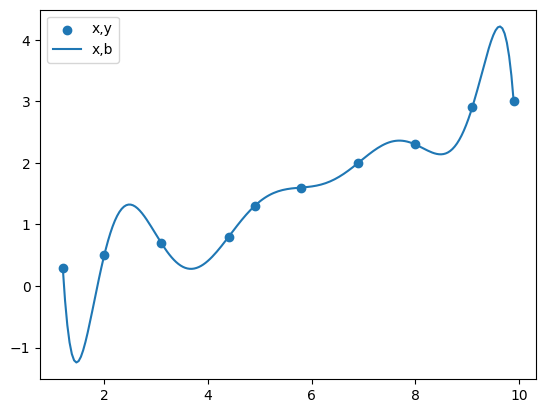

In [17]:
#7.5
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n = len(x)
A  = np.zeros((n,n))
for i in range(len(x)):
    for j in range(len(x)):
        A[i,j] = x[i]**j
        
b = la.solve(A, y)
print(b)

x_plot = np.linspace(min(x), max(x), 200)
y_plot = np.zeros_like(x_plot)
for i in range(len(b)):
    y_plot += b[i]*x_plot**i

fig, ax = plt.subplots()
ax.scatter(x,y, label="x,y")
ax.plot(x_plot,y_plot, label="x,b")
plt.legend()
plt.show()


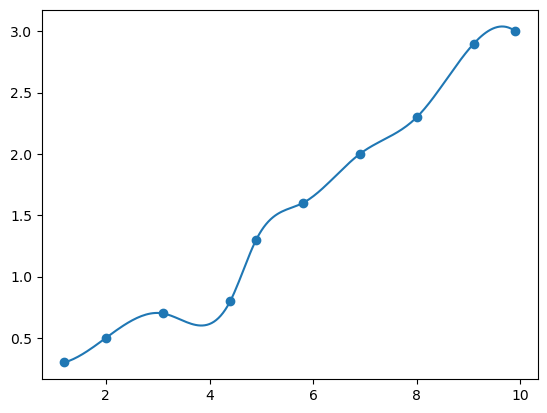

The plot has less extreme deivations in comparison with the figure from 7.5


Enter a value from the list of x:  2
Enter a value from the list of x:  3
Enter a value from the list of x:  4


Linear: 0.5
Polynomial: 0.8356231140268733
Cubic: 0.6136397161926068


In [14]:
#7.6
from scipy.interpolate import interp1d
import numpy as np    
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = interp1d(x, y, kind = 'cubic')
xnew = np.linspace(1.2, 9.9, 200)
ynew = f(xnew)
fig, ax = plt.subplots()
ax.scatter(x,y)
ax.plot(xnew,ynew)
plt.show()
print("The plot has less extreme deivations in comparison with the figure from 7.5")

class Interpolation:
    def __init__(self,x, y):
        self.x = x
        self.y = y

        self.lin = interp1d(self.x, self.y, kind='linear')       #linear interpolation
       
        self.cubic = interp1d(self.x, self.y, kind='cubic')      # Cubic spline interpolation

        self.poly_coeffs = np.polyfit(self.x, self.y, len(self.x) - 1)        # Polynomial interpolation (degree n-1)
        self.poly = np.poly1d(self.poly_coeffs)

    def interpolate(self, method='linear'):
        X = eval(input("Enter a value from the list of x: "))
        if method == 'linear':
            return self.lin(X)

        elif method == 'cubic':
            return self.cubic(X)

        elif method == 'polynomial':
            return self.poly(X)

        else:
            raise ValueError("Method must be 'linear', 'polynomial', or 'spline'")

interp_obj = Interpolation(x, y)          #makes it so that the class is callable for values x and y
y_linear = interp_obj.interpolate(method='linear')         #sets the method to be linear
y_poly = interp_obj.interpolate(method='polynomial')       #sets the method to be polynomial
y_cubic = interp_obj.interpolate(method='cubic')           #sets the method to be cubic

print("Linear:", y_linear)
print("Polynomial:", y_poly)
print("Cubic:", y_cubic)

In [21]:
#7.7
I = np.array([[2.0,4.1], [2.5,3.8]]) #at position x=0.2, y=0.7
print(I)
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")



[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.7,0.2 => x, y=0.20.7 is 2.658000


H0 (leastsq): 66.03148474486585
H0 (curve_fit): 66.0314847885207
Uncertainty: 0.8250819863324016


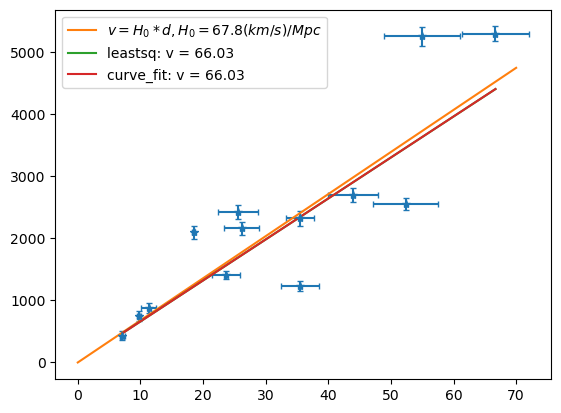

In [30]:
#7.10
import numpy as np
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
from scipy.optimize import leastsq
from scipy.optimize import curve_fit

"""
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
"""
data = np.array([
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ])

d = data[0::4]       
v = data[1::4]
errord = data[2::4]
errorv = data[3::4]

d_axis = np.linspace(0,70,100)
chi = d_axis*67.8        #calulating the fit

def model(d, H0):         #setting up the linear fit 
    return H0 * d

def residuals(params, d, v, errorv):          #The residuals used for the fit
    H0 = params[0]
    return (v - H0 * d) / errorv

H0_guess = [70]       # Initial guess

result = leastsq(residuals, H0_guess, args=(d, v, errorv))         #the result of the fit
H0_leastsq = result[0][0]

print("H0 (leastsq):", H0_leastsq)


popt, pcov = curve_fit(model, d, v, sigma=errorv, absolute_sigma=True)         #the curve fit with errors taken into account

H0_curvefit = popt[0]
H0_err = np.sqrt(np.diag(pcov))[0]

print("H0 (curve_fit):", H0_curvefit)
print("Uncertainty:", H0_err)

d_fit = np.linspace(min(d), max(d), 200)

v_fit_leastsq = H0_leastsq * d_fit
v_fit_curvefit = H0_curvefit * d_fit


fig, ax = plt.subplots()
ax.errorbar(d,v,yerr=errorv,xerr=errord, fmt='*', capsize=2)
ax.plot(d_axis,chi, label =r'$v = H_0*d, H_0 = 67.8 (km/s)/Mpc$')
ax.plot(d_fit, v_fit_leastsq, label=f"leastsq: v = {H0_leastsq:.2f} ")
ax.plot(d_fit, v_fit_curvefit, label=f"curve_fit: v = {H0_curvefit:.2f}")

plt.legend()
show()